In [15]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.cluster import KMeans

california=fetch_california_housing()

X = california.data
y = california.target

In [16]:
df =pd.DataFrame(X, columns = california.feature_names)

# 캘리포니아 데이터
df['MedHouseVal'] = y

## MedInc 와 MedHouseVal의 관계를 간단하게 선형회귀로 확인해 보자!

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## X피처는

X=df[['MedInc']]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=111)

## 성능 확인
model=LinearRegression()
model.fit(X_train, y_train) #학습

# 예측

pred=model.predict(X_test)

mse=mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(mse)
print(r2)

0.7144345630478385
0.46928988803470373


['MedInc', 'AveRooms', 'Latitude']

- Latitude
- 위도 경도를 가지고 컬럼을 추가해서 성능을 개선해보자!

In [17]:
## 위도 경도 가지고 오기
geo_features = ['Latitude','Longitude']
## 두 개 피처 사용하여서 어떤 식으로 전처리 하면 좋을까?
geo_data = df[geo_features]

## 집값이 비싼 곳도 있고 낮은 곳도 있을 수 있다. 가설
## 위도 경도에 따라 군집을 나눠서 집값이 높은 곳과 낮은 곳의 분포를 보고
## 이런 부분을 좀 더 명확하게 머신한테 학습할 수 있도록 피처로 주면 더 좋은 성능이 않을까?

scaler = StandardScaler()
geo_scaled = scaler.fit_transform(geo_data) # 스케일링 작업

In [18]:
## 군집화 진행
kmeans = KMeans(n_clusters = 5, random_state =111)

In [19]:
## geo데이터로 확인
df['cluster']=kmeans.fit_predict(geo_data)
## 5개 군집 생성
## 군집별로의 MedHouseVal 차이가 존재하는지 살펴볼까요?

cluster_avg_prices = df.groupby('cluster')['MedHouseVal'].mean()
print(cluster_avg_prices)

cluster
0    1.166792
1    2.196477
2    1.259732
3    2.003756
4    2.612747
Name: MedHouseVal, dtype: float64


In [20]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,cluster
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,4
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,4
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,4
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,4
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,4
...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,0
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,0
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,0
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,0


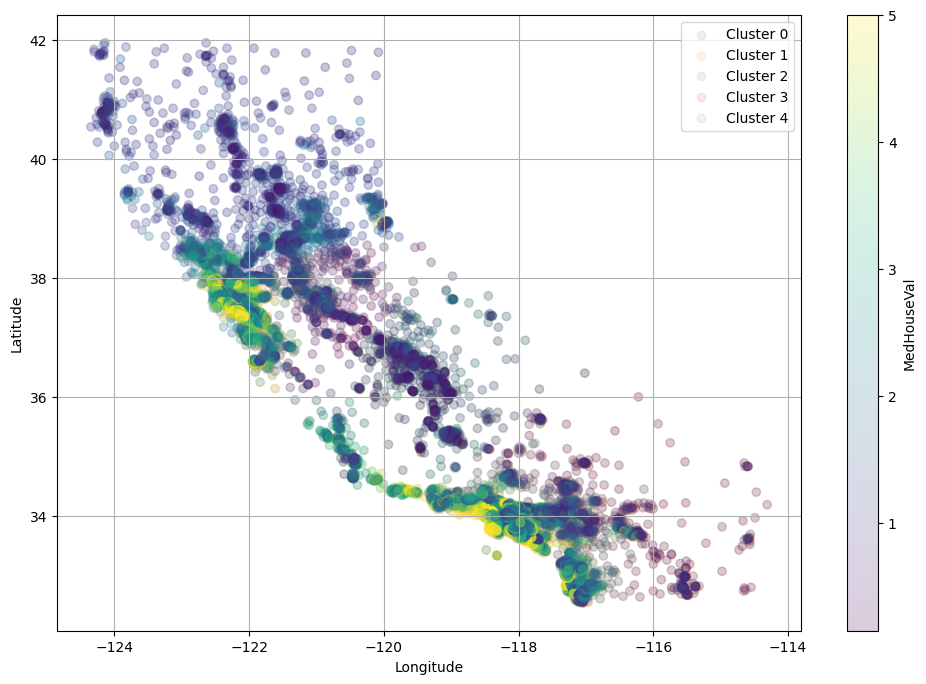

In [22]:
## 위도 경도 기반으로 시각화를 해서 군집이 어떤 식으로 분포되어 있는지 좋을 것 같다.
plt.figure(figsize=(12,8))
for cluster in range(5):
    cluster_data = df[df['cluster']==cluster]
    plt.scatter(
        cluster_data['Longitude'],
        cluster_data['Latitude'],
        label =f'Cluster {cluster}',
        alpha = 0.1
    )

## 색상으로 확인해보기
scatter = plt.scatter(
    df['Longitude'], df['Latitude'], c = df['MedHouseVal'], cmap='viridis', alpha=0.2)
plt.colorbar(scatter, label = 'MedHouseVal')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid()
plt.show()

In [23]:
## 클러스터별 평균 집값을 계산해보자!
df.groupby('cluster')['MedHouseVal'].mean()

cluster
0    1.166792
1    2.196477
2    1.259732
3    2.003756
4    2.612747
Name: MedHouseVal, dtype: float64

In [25]:
## 클러스터별 평균 집값을 기준으로 라벨링
## 함수를 만들어서, 클러스터에 해당하는 평균 집값을 가져오고, 집값이 클러스터 평균보다 높으면 1, 아니면 0 평균에 대비 집값이 높은 곳들은 1로 찍혀서 비싼 집으로 좀 보일 수 있다.

def label_expensive(row):
    cluster_avg = cluster_avg_prices[row['cluster']]
    return 1 if row['MedHouseVal'] > cluster_avg else 0

df['PriceLabel']=df.apply(label_expensive, axis=1)

In [26]:
df['PriceLabel'].value_counts()

PriceLabel
0    12438
1     8202
Name: count, dtype: int64

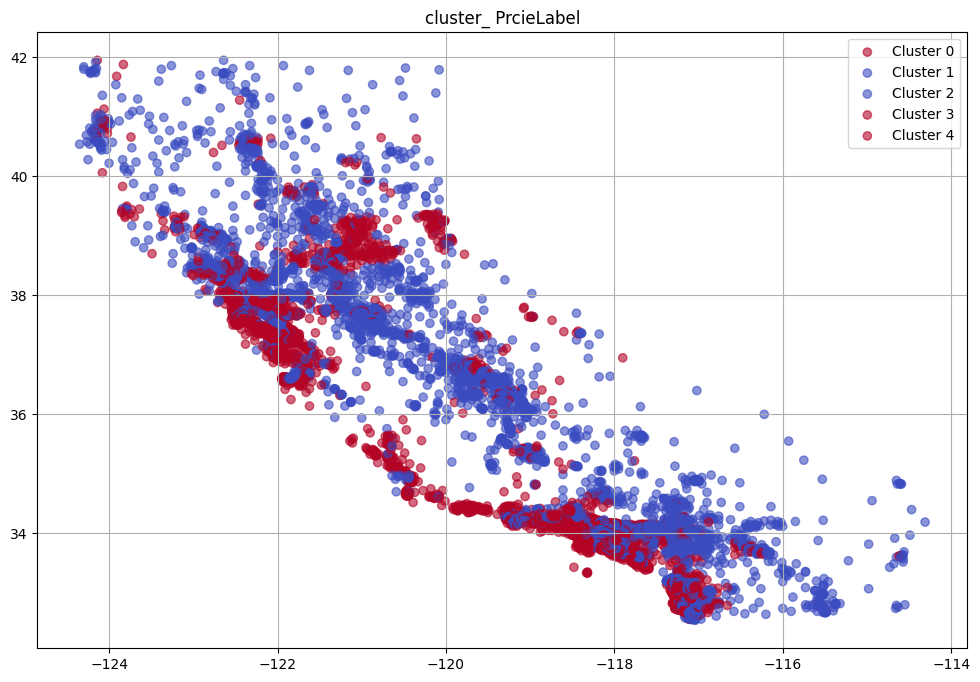

In [27]:
## 위도 경도 기반으로 시각화를 해서 군집이 어떤 식으로 분포되어 있는지 좋을 것 같다.
plt.figure(figsize=(12,8))
for cluster in range(5):
    cluster_data = df[df['cluster']==cluster]
    plt.scatter(
        cluster_data['Longitude'],
        cluster_data['Latitude'],
        c = cluster_data['PriceLabel'],
        cmap = 'coolwarm',
        label=f'Cluster {cluster}',
        alpha=0.6
        )

## 색상으로 확인해 보기 
plt.title('cluster_ PrcieLabel')
plt.legend()
plt.grid()

In [28]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,cluster,PriceLabel
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,4,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,4,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,4,1
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,4,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,4,1
...,...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,0,0
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,0,0
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,0,0
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,0,0


In [29]:
## 새로운 피처를 추가해서 회귀분석을 진행
features = ['MedInc', 'PriceLabel']
X = df[features]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=111)

## 성능확인
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
pred = model.predict(X_test)

mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(mse)
print(r2)

0.4363055857515903
0.6758950388997265


- 'AveRooms' 해당 컬럼을 추가해서 전처리 작업을 진행하자! 

In [38]:
## 최적의 군집은 4로 가정
## 여러분들은 최적의 군집도 잘 찾아서 전처리를 하셔야 합니다.
## 꼭 Kmeans 할 필요 없고, 우리가 배웠던 y값과 관계로 cut나눠도 된다.

ave_rooms=df[['AveRooms']]

In [39]:
## 군집화 진행
kmeans = KMeans(n_clusters = 4, random_state = 111)
## geo데이터 확인
df['cluster_room']=kmeans.fit_predict(ave_rooms)

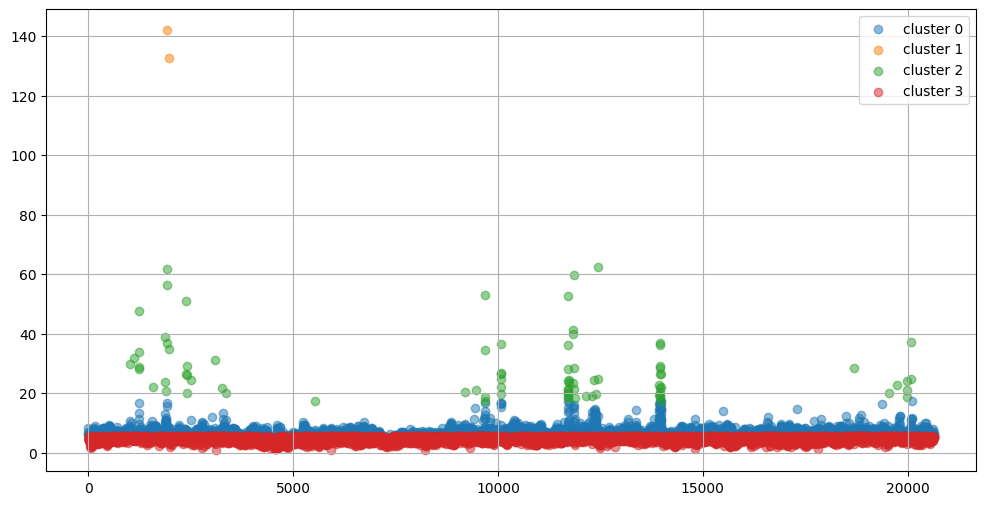

In [41]:
## 군집화 시각화
plt.figure(figsize=(12,6))
for cluster in range(4):
    cluster_data = df[df['cluster_room']==cluster]
    plt.scatter(cluster_data.index, cluster_data['AveRooms'], label=f'cluster {cluster}', alpha=0.5)

plt.legend()
plt.grid()
plt.show()

In [42]:
df['cluster_room'].value_counts()

cluster_room
3    12499
0     8056
2       83
1        2
Name: count, dtype: int64

In [44]:
## 기존 cluster_label을 넣어보자!
## 새로운 피처를 추가해서 회귀분석을 진행
features = ['MedInc', 'PriceLabel', 'cluster_room']
X = df[features]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state=111)

## 성능확인
model = LinearRegression()
model.fit(X_train, y_train)

## 예측
pred = model.predict(X_test)

mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(mse)
print(r2)

0.4189843717853974
0.6887619183577371
